In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

os.makedirs('Data', exist_ok=True)

def save_fig(name):
    plt.savefig(os.path.join('Data', name), dpi=300, bbox_inches='tight')

img_file = 'sar_1_gray.jpg'

## 1. Загрузите изображение в оттенках серого

In [2]:
img = io.imread(img_file)
#img_gray = io.imread(img_file, as_gray=True)
#img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gray = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)

print(img.shape, img_gray.shape, img_gray.dtype)

(400, 600) (400, 600) uint8


## 2. Постройте гистограмму

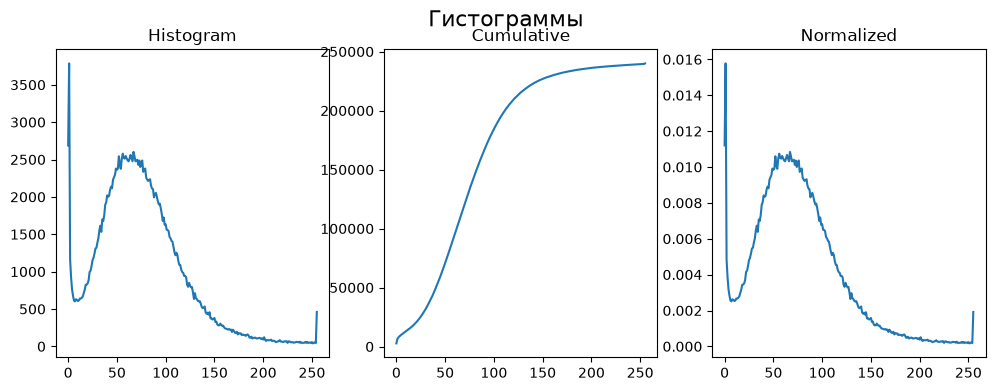

In [3]:
b_hist = cv2.calcHist([img_gray],[0],None,[256],(0,256), accumulate=False)
plt.figure(figsize=(12, 4))
plt.suptitle('Гистограммы', fontsize=16)

plt.subplot(1,3,1)
plt.title('Histogram')
plt.plot(b_hist)

b_hist_cum = b_hist.cumsum()
plt.subplot(1,3,2)
plt.title('Cumulative')
plt.plot(b_hist_cum)

b_hist_norm = b_hist /  (img.shape[0] * img.shape[1])
plt.subplot(1,3,3)
plt.title('Normalized')
plt.plot(b_hist_norm)

save_fig('histograms.png')

## 3. Гамма-коррекция с параметром гамма < 1, > 1

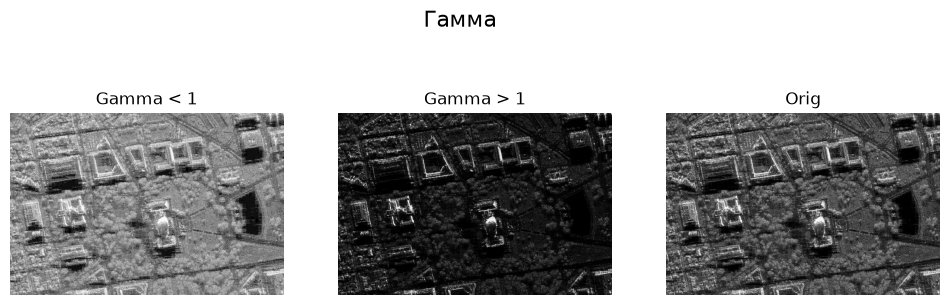

In [4]:
img_norm = img_gray.astype('float32')
img_norm = img_norm / img_norm.max()

def gamma_correction(img_, gamma):
    return np.power(img_, gamma)

gamma_low = 0.5
gamma_high = 2.0

img_gamma_low = gamma_correction(img_norm, gamma_low)
img_gamma_high = gamma_correction(img_norm, gamma_high)

img_gamma_low_8 = (img_gamma_low*255.).astype('uint8')
img_gamma_high_8 = (img_gamma_high*255.).astype('uint8')

plt.figure(figsize=(12, 4))
plt.suptitle('Гамма', fontsize=16)

plt.subplot(1,3,1)
plt.title('Gamma < 1')
plt.imshow(img_gamma_low_8, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title('Gamma > 1')
plt.imshow(img_gamma_high_8, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title('Orig')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

save_fig('gamma.png')

## 4. Сравните исходное изображение и скорректированное (MSE, SSIM)

Gamma < 1 (0.5)
SSIM: 0.7875009063454547
Gamma > 1 (2)
SSIM: 0.5270459697188647


MSE low: 0.04998737992360405
MSE high: 0.03665918959997279


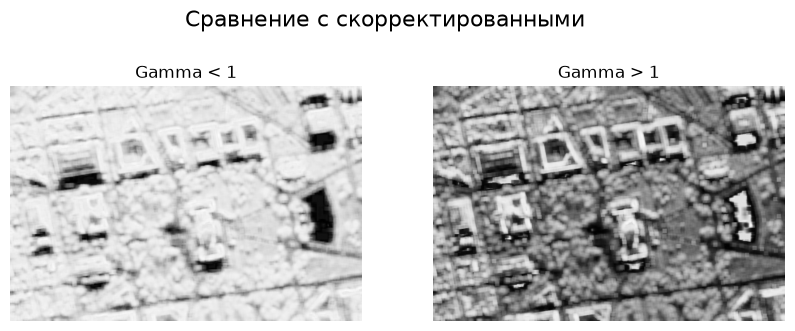

In [5]:
from skimage.metrics import structural_similarity, mean_squared_error

img_gray_f = img_gray.astype('float32')
img_gray_f = img_gray_f / img_gray_f.max()
img_gamma_low_f = img_gamma_low_8.astype('float32') / 255.
img_gamma_high_f = img_gamma_high_8.astype('float32') / 255.

plt.figure(figsize=(10, 4))
plt.suptitle('Сравнение с скорректированными', fontsize=16)

# SSIM gamma < 1
(ssim_low, diff_low) = structural_similarity(img_gray_f, img_gamma_low_f, full=True, data_range=1.0)
diff_low = (diff_low * 255).astype('uint8')

print('Gamma < 1 (0.5)')
print('SSIM: {}'.format(ssim_low))

plt.subplot(1,2,1)
plt.title('Gamma < 1')
plt.imshow(diff_low, cmap='gray')
plt.axis('off')

# SSIM gamma > 1
(ssim_high, diff_high) = structural_similarity(img_gray_f, img_gamma_high_f, full=True, data_range=1.0)
diff_high = (diff_high * 255).astype('uint8')

print('Gamma > 1 (2)')
print('SSIM: {}'.format(ssim_high))

plt.subplot(1,2,2)
plt.title('Gamma > 1')
plt.imshow(diff_high, cmap='gray')
plt.axis('off')

save_fig('comparison.png')

# MSE
mse_low = mean_squared_error(img_gray_f, img_gamma_low_f)
mse_high = mean_squared_error(img_gray_f, img_gamma_high_f)

print('MSE low: {}'.format(mse_low))
print('MSE high: {}'.format(mse_high))

## 5. Статистическая цветокоррекция на основе статистики eq_gray

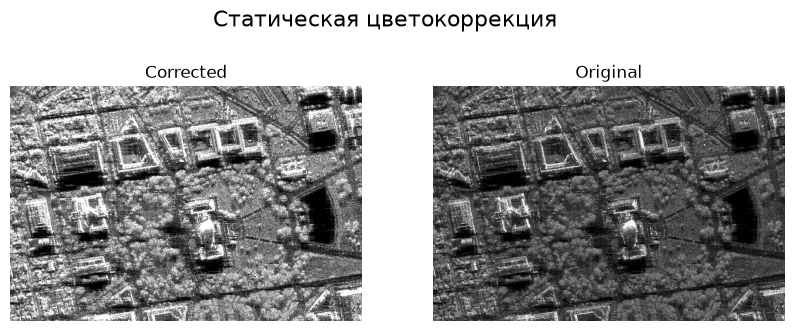

In [6]:
#eq_gray = io.imread('EQ.jpg', as_gray=True).astype('float32')
eq_gray = cv2.equalizeHist(img_gray.astype('uint8'))

src = img_gray.astype('float32')
src /= src.max()
eq = eq_gray.astype('float32')
eq /= eq.max()

mean_src = src.mean()
std_src = src.std()

mean_eq = eq.mean()
std_eq = eq.std()

img_corr = (std_eq / std_src) * (src - mean_src) + mean_eq
img_corr = np.clip(img_corr, 0, 1)
img_corr_8 = (img_corr * 255).astype('uint8')

plt.figure(figsize=(10, 4))
plt.suptitle('Статическая цветокоррекция', fontsize=16)

plt.subplot(1,2,1)
plt.title('Corrected')
plt.imshow(img_corr_8, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title('Original')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

save_fig('color_correction.png')

## 6. Пороговая фильтрация с различными параметрами

Порог Отсу: 85


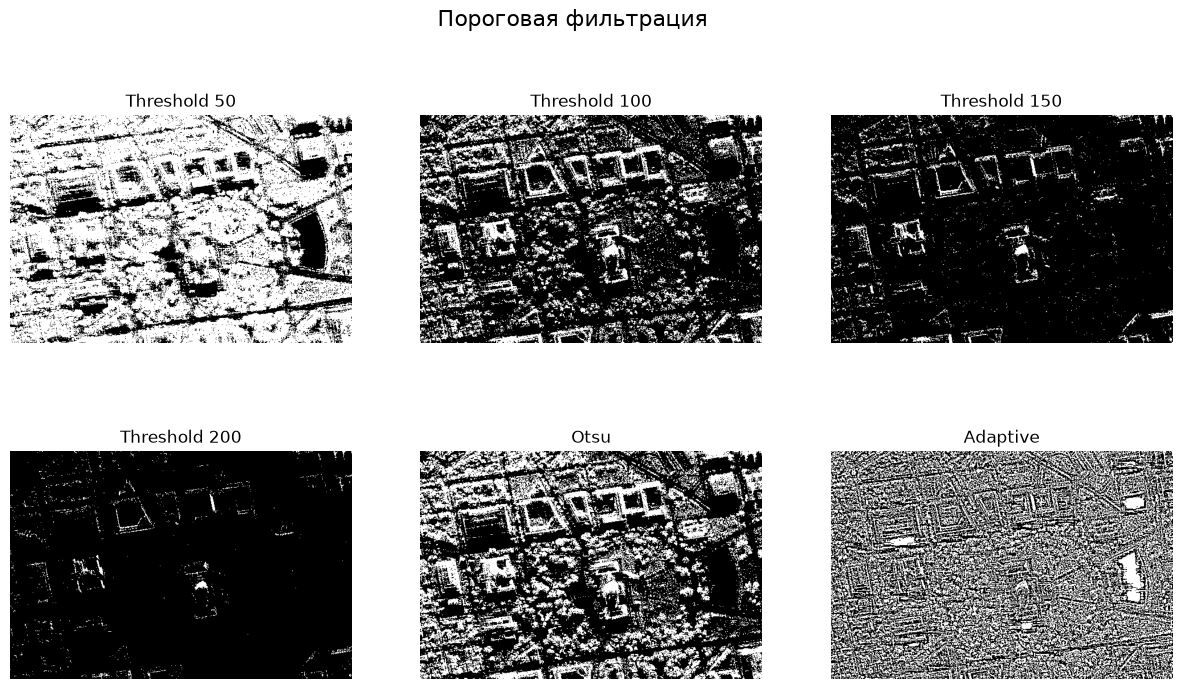

In [7]:
thresholds = [50, 100, 150, 200]

# в исходном Lab1.py: img_u8 = (img_gray * 255).astype('uint8') — но img_gray уже uint8,
# умножение на 255 вызывает переполнение uint8 (значения заворачиваются по модулю 256)
# и искажает результат пороговой фильтрации, поэтому:
img_u8 = img_gray.copy()  # img_gray уже uint8

plt.figure(figsize=(15, 8))
plt.suptitle('Пороговая фильтрация', fontsize=16)

for i, T in enumerate(thresholds):
    _, thresh1 = cv2.threshold(img_u8, T, 255, cv2.THRESH_BINARY)
    plt.subplot(2,3,i+1)
    plt.title('Threshold {}'.format(T))
    plt.imshow(thresh1, cmap='gray')
    plt.axis('off')

_, th_otsu = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.subplot(2,3,5)
plt.title('Otsu')
plt.imshow(th_otsu, cmap='gray')
plt.axis('off')

th_adapt = cv2.adaptiveThreshold(img_u8, 255,
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY,
                                 11, 2)
plt.subplot(2,3,6)
plt.title('Adaptive')
plt.imshow(th_adapt, cmap='gray')
plt.axis('off')

print('Порог Отсу:', int(cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0]))
save_fig('thresholds.png')